In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("D:/Users/HP/Desktop/Sentiment analysis/IMDB Dataset.csv")

In [22]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [23]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [24]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])


Number of rows: 50000
Number of columns: 2


In [25]:
df = df.sample(n = 10000,random_state = 42)
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 10000
Number of columns: 2


In [26]:
df.describe()

,review,sentiment
count,10000,10000
unique,9978,2
top,Leos Carax has made 3 great movies: Boys Meet ...,positive
freq,2,5039


In [27]:
df["sentiment"] = df["sentiment"].map({"positive":1,"negative":0})

In [28]:
df.head()

,review,sentiment
33553,I really liked this Summerslam due to the look...,1
9427,Not many television shows appeal to quite as m...,1
199,The film quickly gets to a major chase scene w...,0
12447,Jane Austen would definitely approve of this o...,1
39489,Expectations were somewhat high for me when I ...,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 33553 to 5857
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 234.4+ KB


In [30]:
# check duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 22


In [31]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [32]:
# check missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 review       0
sentiment    0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_1164\2227695738.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df, palette="pastel")


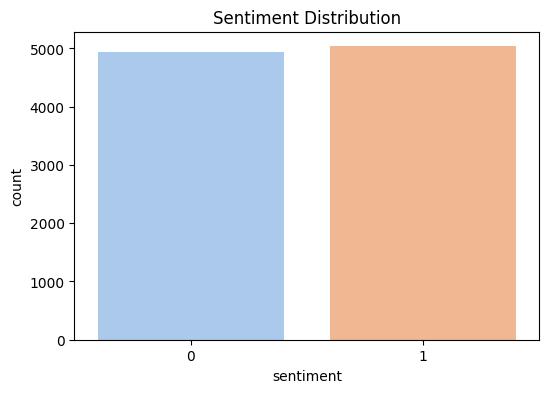

In [33]:
# visualize distribution
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df, palette="pastel")
plt.title("Sentiment Distribution")
plt.show()

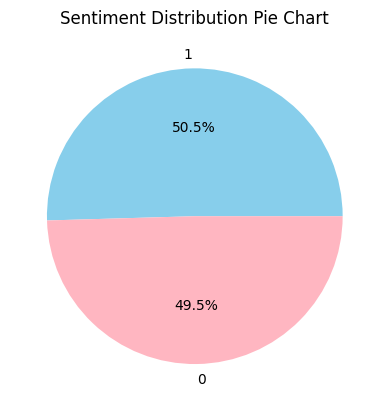

In [34]:
df["sentiment"].value_counts().plot.pie(autopct="%1.1f%%", colors=["skyblue","lightpink"])
plt.title("Sentiment Distribution Pie Chart")
plt.ylabel("")
plt.show()

In [36]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [37]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", text)  
    text = text.lower()                    
    text = text.split()                    
    text = [word for word in text if word not in stop_words]  
    return " ".join(text)

In [38]:
df["cleaned_review"] = df["review"].apply(clean_text)

print(df[["review","cleaned_review"]].head())


                                                  review  \
33553  I really liked this Summerslam due to the look...   
9427   Not many television shows appeal to quite as m...   
199    The film quickly gets to a major chase scene w...   
12447  Jane Austen would definitely approve of this o...   
39489  Expectations were somewhat high for me when I ...   

                                          cleaned_review  
33553  really liked summerslam due look arena curtain...  
9427   many television shows appeal quite many differ...  
199    film quickly gets major chase scene ever incre...  
12447  jane austen would definitely approve one br br...  
39489  expectations somewhat high went see movie thou...  


In [39]:
# Step 5: Split Data
X = df["cleaned_review"]
y = df["sentiment"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)


Train Size: (7982,)
Test Size: (1996,)


In [41]:
# Step 6: Text Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [42]:
# Step 7: Model Training
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [43]:
# Step 8: Model Evaluation
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8667334669338678

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87       989
           1       0.87      0.87      0.87      1007

    accuracy                           0.87      1996
   macro avg       0.87      0.87      0.87      1996
weighted avg       0.87      0.87      0.87      1996



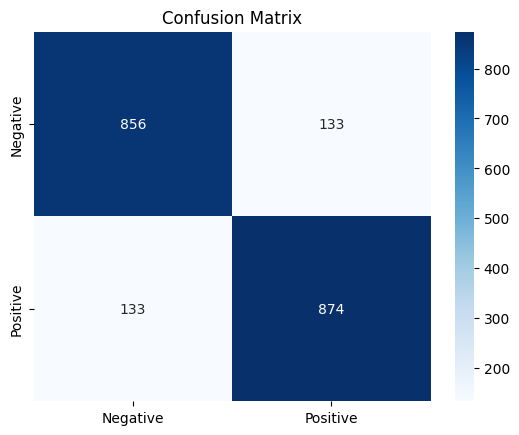

In [44]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative","Positive"], yticklabels=["Negative","Positive"])
plt.title("Confusion Matrix")
plt.show()

In [45]:
# Step 9: Identify Important Words
feature_names = np.array(tfidf.get_feature_names_out())
log_probs = model.feature_log_prob_


In [46]:
top_pos = feature_names[np.argsort(log_probs[1])[-10:]]   
top_neg = feature_names[np.argsort(log_probs[0])[-10:]]
print("Top Positive Words:", top_pos)
print("Top Negative Words:", top_neg)

# Step 10: Save Model and Vectorizer
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

Top Positive Words: ['well' 'see' 'story' 'like' 'good' 'great' 'one' 'film' 'movie' 'br']
Top Negative Words: ['really' 'would' 'good' 'even' 'like' 'one' 'bad' 'film' 'movie' 'br']
